In [1]:
!python --version

Python 3.11.13


In [2]:
!pip show qiskit

Name: qiskit
Version: 2.3.0
Summary: An open-source SDK for working with quantum computers at the level of extended quantum circuits, operators, and primitives.
Home-page: https://www.ibm.com/quantum/qiskit
Author: 
Author-email: Qiskit Development Team <qiskit@us.ibm.com>
License-Expression: Apache-2.0
Location: /home/jirka/miniconda3/envs/VLQ-env/lib/python3.11/site-packages
Requires: dill, numpy, rustworkx, scipy, stevedore, typing-extensions
Required-by: PennyLane-qiskit, qiskit-aer, qiskit-ibm-runtime, qiskit-optimization


In [3]:
!pip show iqm-client

Name: iqm-client
Version: 33.0.4
Summary: Client library for accessing an IQM quantum computer
Home-page: https://pypi.org/project/iqm-client/
Author: 
Author-email: IQM Finland Oy <developers@meetiqm.com>
License: Apache License
                           Version 2.0, January 2004
                        http://www.apache.org/licenses/

   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION

   1. Definitions.

      "License" shall mean the terms and conditions for use, reproduction,
      and distribution as defined by Sections 1 through 9 of this document.

      "Licensor" shall mean the copyright owner or entity authorized by
      the copyright owner that is granting the License.

      "Legal Entity" shall mean the union of the acting entity and all
      other entities that control, are controlled by, or are under common
      control with that entity. For the purposes of this definition,
      "control" means (i) the power, direct or indirect, to cause the
      dire

In [4]:
from fake_vlq import FakeVLQ

/home/jirka/miniconda3/envs/VLQ-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
backend = FakeVLQ()

In [6]:
print(backend)

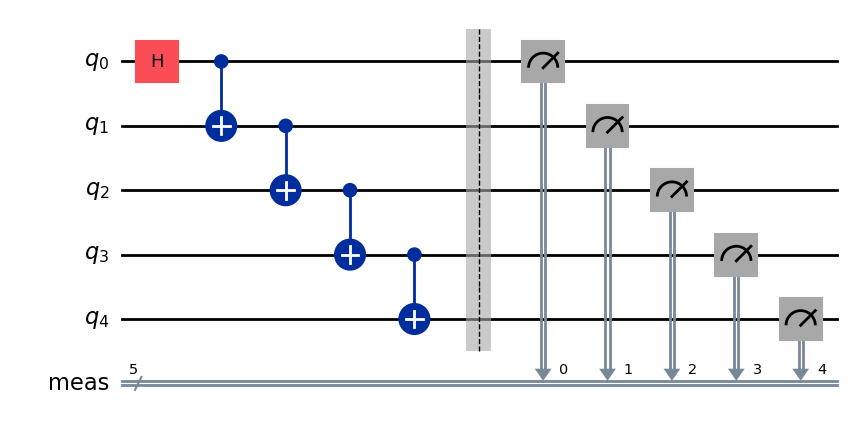

In [7]:
from qiskit import QuantumCircuit

# Define quantum circuit
num_qb = 5
qc = QuantumCircuit(num_qb)
qc.h(0)
for qb in range(1, num_qb):
    qc.cx(qb-1, qb)
qc.measure_all()

qc.draw(output='mpl')

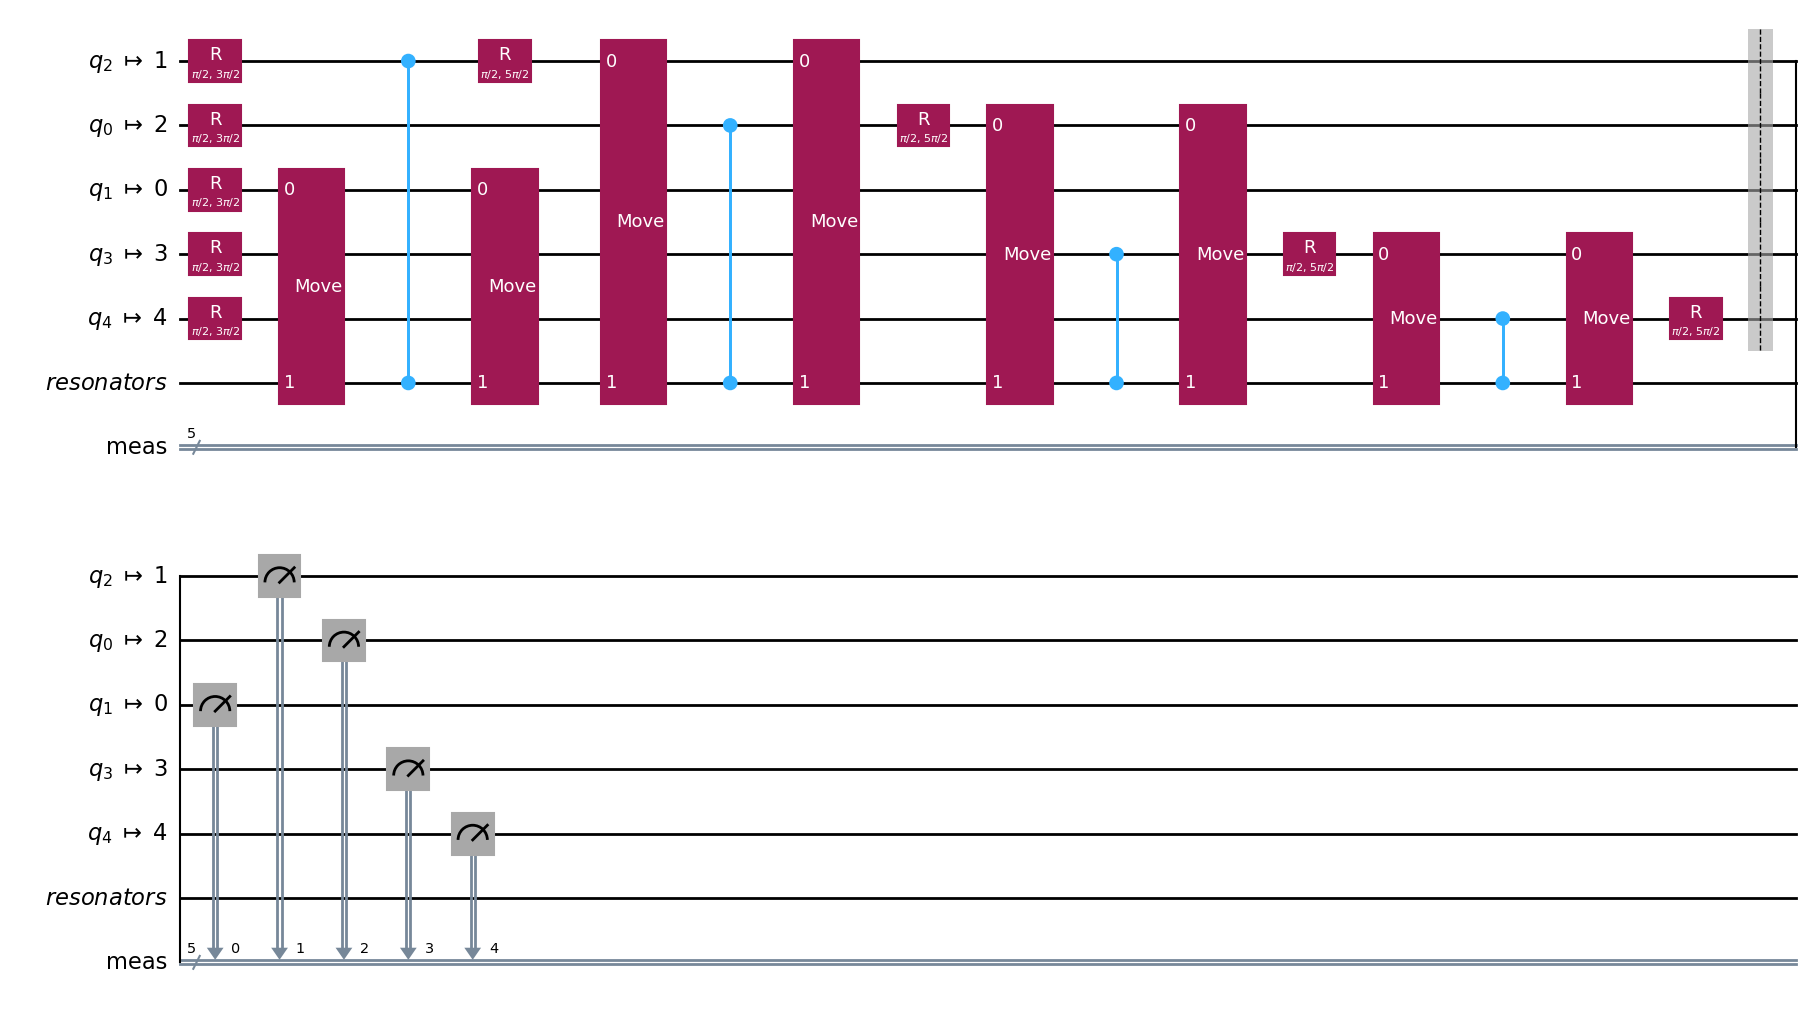

In [8]:
from iqm.qiskit_iqm import  transpile_to_IQM

# Transpile circuit
qc_transpiled = transpile_to_IQM(qc, backend)
qc_transpiled.draw(output="mpl", idle_wires=False)

{'01101': 1, '11001': 1, '01100': 1, '01011': 1, '00011': 4, '00111': 2, '00000': 418, '00010': 13, '11000': 2, '11111': 445, '00100': 9, '11100': 2, '10010': 1, '10111': 8, '00001': 11, '01111': 16, '01000': 11, '11010': 2, '11110': 9, '01110': 2, '11101': 13, '10000': 9, '11011': 19}


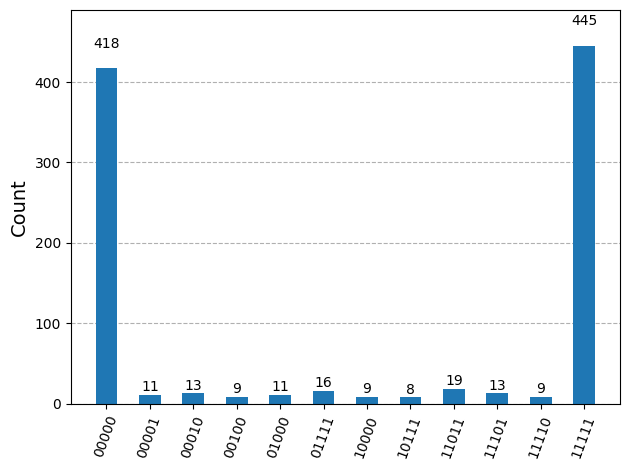

In [9]:
from qiskit.visualization import plot_histogram

# Run circuit
SHOTS = 1000

job = backend.run(qc_transpiled, shots=SHOTS)
print(job.result().get_counts())
results_dict = job.result().get_counts()

# Plot result
result_dict_copy = results_dict
result_dict_clean = {}
counts = 0
for key in result_dict_copy.keys():
    counts+= result_dict_copy[key]
    if result_dict_copy[key] > 5:
        result_dict_clean[key] = result_dict_copy[key]
display(plot_histogram(result_dict_clean))

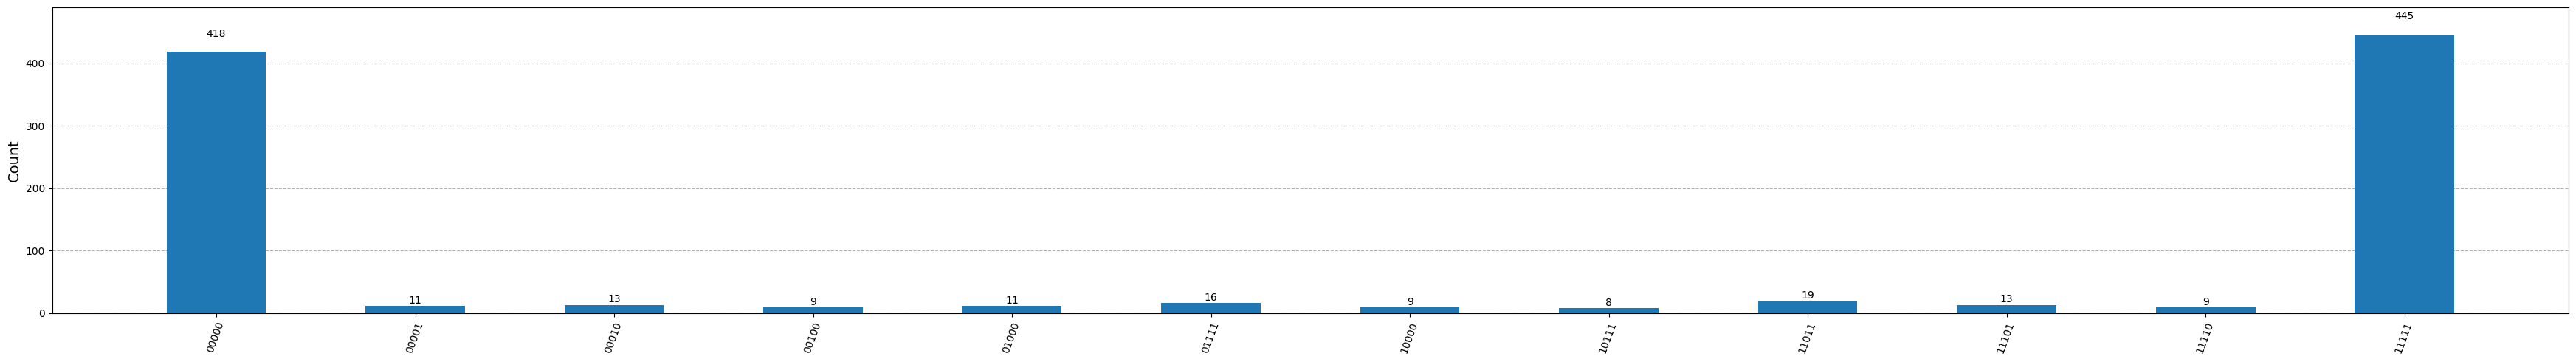

In [10]:
display(plot_histogram(result_dict_clean,figsize=(35,5)))